In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('sales_data.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  str    
 1   Store ID            76000 non-null  str    
 2   Product ID          76000 non-null  str    
 3   Category            76000 non-null  str    
 4   Region              76000 non-null  str    
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  str    
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  str    
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: float64(2), 

In [4]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
df = df.sort_values(['Store ID', 'Product ID', 'Date'])

In [8]:
df = df.reset_index(drop=True)

In [9]:
df['Is_OOS'] = (df['Inventory Level'] == 0).astype(int)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                76000 non-null  datetime64[us]
 1   Store ID            76000 non-null  str           
 2   Product ID          76000 non-null  str           
 3   Category            76000 non-null  str           
 4   Region              76000 non-null  str           
 5   Inventory Level     76000 non-null  int64         
 6   Units Sold          76000 non-null  int64         
 7   Units Ordered       76000 non-null  int64         
 8   Price               76000 non-null  float64       
 9   Discount            76000 non-null  int64         
 10  Weather Condition   76000 non-null  str           
 11  Promotion           76000 non-null  int64         
 12  Competitor Pricing  76000 non-null  float64       
 13  Seasonality         76000 non-null  str           
 14  E

In [11]:
df['Future_OOS'] = df.groupby(['Store ID', 'Product ID'])['Is_OOS'].shift(-1)

In [12]:
df['Prev_Inventory_Level'] = df.groupby(['Store ID', 'Product ID'])['Inventory Level'].shift(1)

In [13]:
df['Prev_Units_Sold'] = df.groupby(['Store ID', 'Product ID'])['Units Sold'].shift(1)

In [14]:
df = df.dropna(subset=['Future_OOS', 'Prev_Inventory_Level', 'Prev_Units_Sold'])

In [15]:
df = df.reset_index(drop=True)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75800 entries, 0 to 75799
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  75800 non-null  datetime64[us]
 1   Store ID              75800 non-null  str           
 2   Product ID            75800 non-null  str           
 3   Category              75800 non-null  str           
 4   Region                75800 non-null  str           
 5   Inventory Level       75800 non-null  int64         
 6   Units Sold            75800 non-null  int64         
 7   Units Ordered         75800 non-null  int64         
 8   Price                 75800 non-null  float64       
 9   Discount              75800 non-null  int64         
 10  Weather Condition     75800 non-null  str           
 11  Promotion             75800 non-null  int64         
 12  Competitor Pricing    75800 non-null  float64       
 13  Seasonality           75800

In [17]:
rolling_avg = df.groupby(['Store ID', 'Product ID'])['Units Sold'].rolling(7, min_periods=1).mean()

In [18]:
rolling_avg = rolling_avg.reset_index(drop=True)

In [19]:
df['Rolling_7d_Units_Sold'] = rolling_avg

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75800 entries, 0 to 75799
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   75800 non-null  datetime64[us]
 1   Store ID               75800 non-null  str           
 2   Product ID             75800 non-null  str           
 3   Category               75800 non-null  str           
 4   Region                 75800 non-null  str           
 5   Inventory Level        75800 non-null  int64         
 6   Units Sold             75800 non-null  int64         
 7   Units Ordered          75800 non-null  int64         
 8   Price                  75800 non-null  float64       
 9   Discount               75800 non-null  int64         
 10  Weather Condition      75800 non-null  str           
 11  Promotion              75800 non-null  int64         
 12  Competitor Pricing     75800 non-null  float64       
 13  Seasonality 

In [21]:
df['Day_Of_Week'] = df['Date'].dt.dayofweek

In [22]:
df['Month'] = df['Date'].dt.month

In [23]:
df = df.drop(columns=['Store ID', 'Product ID', 'Date', 'Inventory Level', 'Is_OOS'])

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75800 entries, 0 to 75799
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Category               75800 non-null  str    
 1   Region                 75800 non-null  str    
 2   Units Sold             75800 non-null  int64  
 3   Units Ordered          75800 non-null  int64  
 4   Price                  75800 non-null  float64
 5   Discount               75800 non-null  int64  
 6   Weather Condition      75800 non-null  str    
 7   Promotion              75800 non-null  int64  
 8   Competitor Pricing     75800 non-null  float64
 9   Seasonality            75800 non-null  str    
 10  Epidemic               75800 non-null  int64  
 11  Demand                 75800 non-null  int64  
 12  Future_OOS             75800 non-null  float64
 13  Prev_Inventory_Level   75800 non-null  float64
 14  Prev_Units_Sold        75800 non-null  float64
 15  Rolling_7d_Un

In [25]:
df = pd.get_dummies(df, columns=['Category', 'Region', 'Weather Condition', 'Seasonality'])

In [26]:
df.head(10)

,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand,Future_OOS,Prev_Inventory_Level,...,Region_South,Region_West,Weather Condition_Cloudy,Weather Condition_Rainy,Weather Condition_Snowy,Weather Condition_Sunny,Seasonality_Autumn,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter
0,71,0,65.63,5,0,73.66,0,84,0.0,195.0,...,False,False,False,False,True,False,False,False,False,True
1,142,229,68.55,15,1,80.73,0,132,0.0,93.0,...,False,False,False,False,True,False,False,False,False,True
2,42,0,61.66,10,0,54.88,0,67,0.0,274.0,...,False,False,False,False,True,False,False,False,False,True
3,129,0,59.56,25,1,57.34,0,110,0.0,132.0,...,False,False,False,False,True,False,False,False,False,True
4,98,308,84.03,0,0,95.54,0,146,0.0,319.0,...,False,False,False,False,False,True,False,False,False,True
5,92,0,66.07,10,0,63.57,0,87,0.0,190.0,...,False,False,False,False,True,False,False,False,False,True
6,96,248,68.56,10,1,80.99,0,113,0.0,92.0,...,False,False,False,False,True,False,False,False,False,True
7,57,0,62.76,10,0,67.11,0,87,0.0,308.0,...,False,False,False,False,False,True,False,False,False,True
8,88,0,68.99,5,0,81.14,0,99,0.0,212.0,...,False,False,True,False,False,False,False,False,False,True
9,112,0,73.71,0,0,85.29,0,103,0.0,403.0,...,False,False,True,False,False,False,False,False,False,True


In [27]:
X = df.drop(columns=['Future_OOS'])

In [28]:
y = df['Future_OOS']

In [29]:
print(X.shape)

(75800, 30)


In [30]:
print(y.value_counts())

Future_OOS
0.0    75400
1.0      400
Name: count, dtype: int64


In [31]:
correlations = X.corrwith(y)
correlations_sorted = correlations.sort_values(ascending=False)

In [32]:
print(correlations_sorted)

Units Ordered               0.086308
Demand                      0.078608
Prev_Units_Sold             0.058621
Units Sold                  0.039017
Promotion                   0.031048
Discount                    0.020854
Weather Condition_Sunny     0.018607
Category_Groceries          0.016354
Rolling_7d_Units_Sold       0.011818
Price                       0.009829
Competitor Pricing          0.008891
Seasonality_Winter          0.006626
Day_Of_Week                 0.005090
Region_South                0.004552
Region_East                 0.001821
Seasonality_Summer         -0.000466
Region_West                -0.000910
Category_Electronics       -0.001681
Seasonality_Autumn         -0.002149
Weather Condition_Cloudy   -0.002513
Category_Toys              -0.002624
Seasonality_Spring         -0.004289
Region_North               -0.004460
Category_Clothing          -0.004967
Weather Condition_Rainy    -0.009225
Weather Condition_Snowy    -0.009894
Month                      -0.010994
C

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [35]:
print('X_train shape: ', X_train.shape) 
print('X_test shape: ', X_test.shape)
print('y_train shape: ', y_train.shape)
print('y_test shape: ',  y_train.shape)

X_train shape:  (60640, 30)
X_test shape:  (15160, 30)
y_train shape:  (60640,)
y_test shape:  (60640,)


In [36]:
from imblearn.over_sampling import SMOTE

In [37]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [38]:
y_train.value_counts()

Future_OOS
0.0    60320
1.0      320
Name: count, dtype: int64

In [39]:
y_train_balanced.value_counts()

Future_OOS
0.0    60320
1.0    60320
Name: count, dtype: int64

In [40]:
from sklearn.linear_model import LogisticRegression

In [41]:
log_model = LogisticRegression(max_iter=10000, random_state=42)

In [42]:
log_model.fit(X_train_balanced, y_train_balanced)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [43]:
predictions = log_model.predict(X_test)

In [44]:
from sklearn.metrics import classification_report, roc_auc_score

In [45]:
probability_table = log_model.predict_proba(X_test)

In [46]:
probability_of_out_of_stock = probability_table[:, 1]

In [47]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     15080
         1.0       0.14      0.10      0.12        80

    accuracy                           0.99     15160
   macro avg       0.57      0.55      0.56     15160
weighted avg       0.99      0.99      0.99     15160



In [48]:
print("ROC-AUC:", roc_auc_score(y_test, probability_of_out_of_stock))

ROC-AUC: 0.8459225795755969


In [49]:
from sklearn.ensemble import RandomForestClassifier

In [50]:
rf_model = RandomForestClassifier(random_state=42)

In [51]:
rf_model.fit(X_train_balanced, y_train_balanced)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [52]:
rf_predictions = rf_model.predict(X_test)

In [53]:
rf_probability_table = rf_model.predict_proba(X_test)

In [54]:
rf_probability_of_out_of_stock = rf_probability_table[:, 1]

In [55]:
print(classification_report(y_test, rf_predictions))
print()
print("ROC-AUC:", roc_auc_score(y_test, rf_probability_of_out_of_stock))

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     15080
         1.0       0.00      0.00      0.00        80

    accuracy                           0.99     15160
   macro avg       0.50      0.50      0.50     15160
weighted avg       0.99      0.99      0.99     15160


ROC-AUC: 0.9334549071618037


In [56]:
lowered_predictions = (rf_probability_of_out_of_stock > 0.2).astype(int)

In [57]:
print(classification_report(y_test, lowered_predictions))

              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99     15080
         1.0       0.10      0.15      0.12        80

    accuracy                           0.99     15160
   macro avg       0.55      0.57      0.56     15160
weighted avg       0.99      0.99      0.99     15160



In [58]:
import lightgbm as lgb

In [59]:
lgb_model = lgb.LGBMClassifier(random_state=42)

In [60]:
lgb_model.fit(X_train_balanced, y_train_balanced)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 60320, number of negative: 60320
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035283 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2124
[LightGBM] [Info] Number of data points in the train set: 120640, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [61]:
lgb_predictions = lgb_model.predict(X_test)

In [62]:
lgb_probability_table = lgb_model.predict_proba(X_test)

In [63]:
lgb_probability_of_out_of_stock = lgb_probability_table[:, 1]

In [64]:
print(classification_report(y_test, lgb_predictions))
print()
print("ROC-AUC:", roc_auc_score(y_test, lgb_probability_of_out_of_stock))

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     15080
         1.0       0.24      0.05      0.08        80

    accuracy                           0.99     15160
   macro avg       0.62      0.52      0.54     15160
weighted avg       0.99      0.99      0.99     15160


ROC-AUC: 0.944068302387268


In [65]:
lgb_lowered_predictions = (lgb_probability_of_out_of_stock > 0.2).astype(int)

In [66]:
print(classification_report(y_test, lgb_lowered_predictions))

              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99     15080
         1.0       0.17      0.26      0.20        80

    accuracy                           0.99     15160
   macro avg       0.58      0.63      0.60     15160
weighted avg       0.99      0.99      0.99     15160



In [67]:
from sklearn.model_selection import GridSearchCV

In [68]:
param_grid = {'n_estimators': [100, 200], 'max_depth': [3, 5, 7],
              'learning_rate': [0.05, 0.1],'num_leaves': [15, 31]}

In [69]:
lgb_base_model = lgb.LGBMClassifier(random_state=42)

In [70]:
grid_search = GridSearchCV(estimator=lgb_base_model, param_grid=param_grid, scoring='roc_auc', cv=5, n_jobs=-1)

In [71]:
grid_search.fit(X_train_balanced, y_train_balanced)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 60320, number of negative: 60320
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044951 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2124
[LightGBM] [Info] Number of data points in the train set: 120640, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], 'num_leaves': [15, 31]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose:

In [72]:
print("Best parameters:", grid_search.best_params_)

Best parameters: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'num_leaves': 31}


In [73]:
print("Best cross-validation ROC-AUC:", grid_search.best_score_)

Best cross-validation ROC-AUC: 0.9998473836378399


In [74]:
from imblearn.pipeline import Pipeline

In [75]:
pipeline = Pipeline([('smote', SMOTE(random_state=42)),
                     ('model', lgb.LGBMClassifier(random_state=42))])

In [76]:
param_grid = {'model__n_estimators': [100, 200], 'model__max_depth': [3, 5, 7],
              'model__learning_rate': [0.05, 0.1], 'model__num_leaves': [15, 31]}

In [77]:
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid,
                           scoring='roc_auc', cv=5, n_jobs=-1)

In [78]:
grid_search.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 60320, number of negative: 60320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.089560 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2124
[LightGBM] [Info] Number of data points in the train set: 120640, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200], 'model__num_leaves': [15, 31]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable add

In [79]:
print("Best parameters:", grid_search.best_params_)
print()
print("Best cross-validation ROC-AUC:", grid_search.best_score_)

Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 200, 'model__num_leaves': 31}

Best cross-validation ROC-AUC: 0.9461227619363395


In [80]:
best_pipeline = Pipeline([('smote', SMOTE(random_state=42)), 
                          ('model', lgb.LGBMClassifier(learning_rate=0.1, max_depth=7,
                                                       n_estimators=200, num_leaves=31, random_state=42))])

In [81]:
best_pipeline.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 60320, number of negative: 60320
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041633 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2124
[LightGBM] [Info] Number of data points in the train set: 120640, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[float64](2,)","[0.,1.]"
feature_names_in_,"ndarray[object](30,)","['Units Sold','Units Ordered','Price',...,'Seasonality_Spring', 'Seasonality_Summer','Seasonality_Winter']"
n_features_in_,int,30
,random_state,42
,sampling_strategy,'auto'
,k_neighbors,5


In [86]:
best_predictions = best_pipeline.predict(X_test)

In [87]:
best_probability_table = best_pipeline.predict_proba(X_test)

In [88]:
best_probability_of_out_of_stock = best_probability_table[:, 1]

In [89]:
print(classification_report(y_test, best_predictions))
print("ROC-AUC:", roc_auc_score(y_test, best_probability_of_out_of_stock))

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     15080
         1.0       0.29      0.05      0.09        80

    accuracy                           0.99     15160
   macro avg       0.64      0.52      0.54     15160
weighted avg       0.99      0.99      0.99     15160

ROC-AUC: 0.9375472480106101


In [90]:
best_lowered_predictions = (best_probability_of_out_of_stock > 0.2).astype(int)

In [91]:
print(classification_report(y_test, best_lowered_predictions))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     15080
         1.0       0.16      0.15      0.15        80

    accuracy                           0.99     15160
   macro avg       0.58      0.57      0.57     15160
weighted avg       0.99      0.99      0.99     15160



In [92]:
pip install shap

   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/43.0 MB 439.3 kB/s eta 0:01:37
   ---------------------------------------- 0.5/43.0 MB 439.3 kB/s eta 0:01:37
   ---------------------------------------- 0.5/43.0 MB 439.3 kB/s eta 0:01:37
    --------------------------------------- 0.8/43.0 MB 420.0 kB/s eta 0:01:41
    --------------------------------------- 0.8/43.0 MB 420.0 kB/s eta 0:01:41
    --------------------------------------- 0.8/43.0 MB 420.0 kB/s eta 0:01:41
    --------------------------------------- 1.0/43.0 MB 407.4 kB/s eta 0:01:43
    -----------------------

In [93]:
import shap

In [94]:
trained_lgb_model = best_pipeline.named_steps['model']

In [95]:
explainer = shap.TreeExplainer(trained_lgb_model)

In [96]:
shap_values = explainer.shap_values(X_test)

C:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [97]:
print(type(shap_values))

<class 'numpy.ndarray'>


In [99]:
print(np.array(shap_values).shape)

(15160, 30)


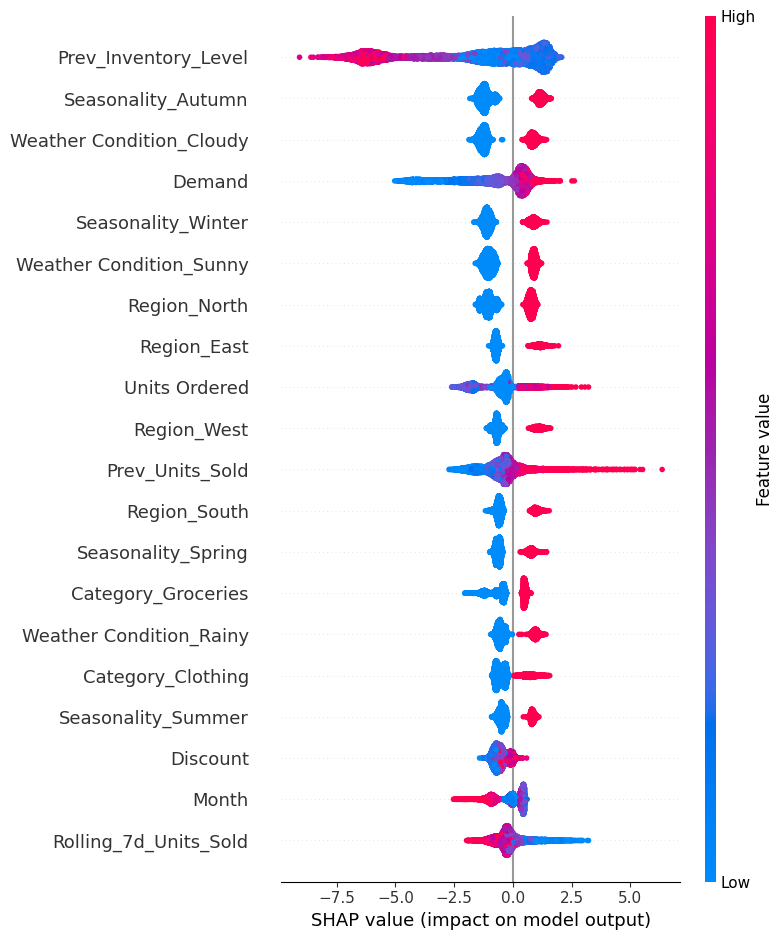

In [100]:
shap.summary_plot(shap_values, X_test)

In [101]:
pip install mlflow

   ---------------------------------------- 0.0/11.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.2 MB 2.9 MB/s eta 0:00:04
   --- ------------------------------------ 1.0/11.2 MB 3.1 MB/s eta 0:00:04
   ------ --------------------------------- 1.8/11.2 MB 2.9 MB/s eta 0:00:04
   --------- ------------------------------ 2.6/11.2 MB 3.0 MB/s eta 0:00:03
   ----------- ---------------------------- 3.1/11.2 MB 2.9 MB/s eta 0:00:03
   ------------- -------------------------- 3.7/11.2 MB 2.8 MB/s eta 0:00:03
   -------------- ------------------------- 4.2/11.2 MB 2.9 MB/s eta 0:00:03
   ---------------- ----------------------- 4.7/11.2 MB 2.8 MB/s eta 0:00:03
   ------------------ --------------------- 5.2/11.2 MB 2.8 MB/s eta 0:00:03
   -------------------- ------------------- 5.8/11.2 MB 2.7 MB/s eta 0:00:02
   ---------------------- ----------------- 6.3/11.2 MB 2.7 MB/s eta 0:00:02
   ------------------------ --------------- 6.8/11.2 MB 2.7 MB/s eta 0:00:02
   ---

  You can safely remove it manually.


In [102]:
import mlflow

In [103]:
mlflow.set_experiment("Retail_OOS_Prediction")

2026/08/28 08:52:03 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/28 08:52:03 INFO mlflow.store.db.utils: Updating database tables
2026/08/28 08:52:05 INFO mlflow.tracking.fluent: Experiment with name 'Retail_OOS_Prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:C:/Users/HP/Downloads/CodeRoomHub/Capstone/mlruns/1', creation_time=1787889125897, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1787889125897, lifecycle_stage='active', name='Retail_OOS_Prediction', tags={}, trace_location=None, workspace='default'>

In [104]:
with mlflow.start_run(run_name="Logistic_Regression_Baseline"):
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("max_iter", 10000)
    
    mlflow.log_metric("roc_auc", 0.846)
    mlflow.log_metric("precision_class1", 0.14)
    mlflow.log_metric("recall_class1", 0.10)
    mlflow.log_metric("f1_class1", 0.12)

In [105]:
with mlflow.start_run(run_name="Random_Forest"):
    mlflow.log_param("model_type", "RandomForestClassifier")
    mlflow.log_param("random_state", 42)
    
    mlflow.log_metric("roc_auc", 0.933)
    mlflow.log_metric("precision_class1_threshold_0.2", 0.10)
    mlflow.log_metric("recall_class1_threshold_0.2", 0.15)
    mlflow.log_metric("f1_class1_threshold_0.2", 0.12)

In [106]:
with mlflow.start_run(run_name="LightGBM_Default"):
    mlflow.log_param("model_type", "LGBMClassifier")
    mlflow.log_param("tuned", False)
    
    mlflow.log_metric("roc_auc", 0.944)
    mlflow.log_metric("precision_class1_threshold_0.2", 0.17)
    mlflow.log_metric("recall_class1_threshold_0.2", 0.26)
    mlflow.log_metric("f1_class1_threshold_0.2", 0.20)

In [107]:
with mlflow.start_run(run_name="LightGBM_Tuned_Final"):
    mlflow.log_param("model_type", "LGBMClassifier")
    mlflow.log_param("tuned", True)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("max_depth", 7)
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("num_leaves", 31)
    
    mlflow.log_metric("cv_roc_auc", 0.9461)
    mlflow.log_metric("test_roc_auc", 0.9375)
    mlflow.log_metric("precision_class1_threshold_0.2", 0.16)
    mlflow.log_metric("recall_class1_threshold_0.2", 0.15)
    mlflow.log_metric("f1_class1_threshold_0.2", 0.15)

In [108]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [110]:
import joblib

In [111]:
joblib.dump(best_pipeline, 'oos_prediction_model.pkl')

['oos_prediction_model.pkl']

In [112]:
joblib.dump(list(X.columns), 'model_columns.pkl')

['model_columns.pkl']

In [113]:
import os

In [114]:
print(os.listdir())

['.ipynb_checkpoints', 'mlflow.db', 'model_columns.pkl', 'oos_prediction_model.pkl', 'sales_data.csv', 'Untitled.ipynb']
